<h1 dir="rtl" style="font-family: Vazir; width: 85%;">تمرین شماره 4
: درس بازیابی هوشمند اطلاعات - دانشگاه تهران، پائیز ۱۴۰۳</h1>

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
نام: عرفان شهابی
<br/>


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
سوالات خودتان را می‌توانید از طریق ایمیل
<code>Hoomanshirvani@ut.ac.ir</code>
 از طراح تمرین 4 بپرسید.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px; color: red; font-weight: bold;">
قوانین و توضیحاتی آخر فایل تمرین حتما به دقت مطالعه شود.
</div>

# **سوال اول:**

<div style="direction: rtl; text-align: right;">
در این کد سعی بر آن شده داده های مربوط به نظرات کاربران imdb بارگذاری و پیش پردازش شود.
ابتدا کتابخانه های لازم برای اجرای این کد ایمپورت شده است. کتابخانه os برای دسترسی به مسیر فایل و خوندن فایل در دایرکتوری، کتابخانه pandas برای ندیریت داده ها، کتابخانه re برای انحام عملیات های جست و جو و جایگزینی با استفاده از عبارات منظرم، کتابخانه nltk.corpus.stopwords که شامل استاپ ورد هاست و کتابخانه nltk.tokenize.woord_tokenize که برای توکنایز کردن متن استفاده می شود.
سپس مسیر فایل داده مشخص شده است و بااستفاده از تابع load_data که نوشته شده نظرات هر یک از دسته های مقبت و منفی بارگذاری شده است. پس از بارگذاری نظرات مثبت و منفی این دو لیست در یک دیتا فریم پانداس ذخیره می شوند به صورتی که ستون اول شامل متن نظرات و ستون دوم شامل لیبل های ۰ و ۱ است.
پس از بارگذارب داده  ها ، تعداد نظرات مثبت و منفی با استفاده از متد sum() برای ستون sentiment محاسبه و نمایش داده می شود.
در مرحله بعد پیش پردازش انجام شده و با استفاده از متد lower() متن به حروف کوچک تبدیل می شود
و همچنین استاپ ورد ها از داده حذف می شوند.
بعد از اعمال پیش پردازش ۵ نظر اول نمایش داده میشود تا بررسی کنیم پیش پردازش به درستی انجام شده است یا خیر.

In [34]:
import os
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

base_path = '/Users/erfanshahabi/Desktop/uni/IIR/CA4/aclImdb'

def load_data(base_path, sentiment):
    reviews = []
    path = os.path.join(base_path, sentiment)
    for file_name in os.listdir(path):
        with open(os.path.join(path, file_name), 'r', encoding='utf-8') as file:
            reviews.append(file.read().strip())
    return reviews

positive_reviews = load_data(base_path, 'train/pos')
negative_reviews = load_data(base_path, 'train/neg')
data = pd.DataFrame({
    'review': positive_reviews + negative_reviews,
    'sentiment': [1] * len(positive_reviews) + [0] * len(negative_reviews)
})


print(f"positive reviews {data['sentiment'].sum()}")
print(f"negative reviews {len(data) - data['sentiment'].sum()}")

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    
    text = re.sub(r'[^\w\s]', '', text)

    text = text.lower()
   
    words = word_tokenize(text)
    text = ' '.join([word for word in words if word not in stop_words])
    return text

data['review'] = data['review'].apply(preprocess_text)

print("\n5 first reviews after preprocessing:")
print(data['review'].head())


positive reviews 12500
negative reviews 12500

5 first reviews after preprocessing:
0    movie gets respect sure lot memorable quotes l...
1    bizarre horror movie filled famous faces stole...
2    solid unremarkable film matthau einstein wonde...
3    strange feeling sit alone theater occupied par...
4    probably already know 5 additional episodes ne...
Name: review, dtype: object


<div style="direction: rtl; text-align: right;">
در این کد مدل های از پیش آموزش دیده word2vec, glove بارگزاری شده اند و سعی شده با استفاده از این مدل ها بردار ویژگی برای هر نظر در داده ها استخراح شود.
در مرحله اول کتابخانه های مورد نیاز ایمپور شده اند. از کتابخانه genism.model.keyedvectors برای بارگذاری و استفاده از مدل work2vec که شامل کلمات و بردار هاب آن هاست استفاده می شود.
مسیر مدل word2vec از پیش‌آموزش دیده (در اینجا مدل Google News Word2Vec با ابعاد 300) در متغیر word2vec_path قرار دارد.
با استفاده از تابع load_word2vec_format مدل word2vec بارگذاری می‌شود. این مدل به صورت باینری (binary) بارگذاری می‌شود تا بتوان از آن برای استخراج بردارهای معنایی کلمات استفاده کرد.
سپس تابع get_mean_vector برای محاسبه بردار میانگین کلمات ورودی (words) تعریف شده است. در این تابع:
ابتدا بردارهای معنایی کلمات موجود در مدل برای کلمات ورودی استخراج می‌شود.
اگر کلمات موجود در مدل پیدا شدند، میانگین آنها محاسبه می‌شود.
در صورتی که هیچ کلمه‌ای در مدل پیدا نشد، یک بردار صفر به اندازه ابعاد مدل (300) برگشت داده می‌شود.
در مرحله بعدی  برای هر نظر در داده‌ها (data['review'])، با استفاده از تابع apply، کلمات نظر به وسیله تابع split() به لیست کلمات تبدیل شده و سپس تابع get_mean_vector برای استخراج بردار میانگین اعمال می‌شود.
این بردار میانگین در ستون word2vec_vector از DataFrame ذخیره می‌شود.
برای به دست آوردن بردار نظرات با استفاده از مدل glove ابتدا این مدل را با استفاده از متغیر glove_path که آدرس فایل مدل در آن قرار دارد را وارد برنامه میکنیم. مدل GloVe به صورت متنی است و برای بارگذاری آن از دستور open استفاده می‌شود تا فایل را خوانده و کلمات همراه با بردارهایشان را در یک دیکشنری به نام glove_model ذخیره کنیم.
سپس تابع get_mean_vector_glove را تعریف می کنیم که تابع get_mean_vector_glove مشابه با تابع get_mean_vector برای مدل word2Vec تعریف شده است:
ابتدا بردارهای معنایی کلمات ورودی از مدل glove استخراج می‌شود.
اگر کلمات موجود در مدل پیدا شدند، میانگین آنها محاسبه می‌شود.
در صورتی که هیچ کلمه‌ای در مدل پیدا نشد، یک بردار صفر با ابعاد 300 برگشت داده می‌شود. سپس مشابه با بخش قبلی، برای هر نظر در داده‌ها (data['review'])، کلمات نظر به وسیله تابع split() به لیست کلمات تبدیل می‌شود و سپس تابع get_mean_vector_glove برای استخراج بردار میانگین GloVe اعمال می‌شود.
این بردار میانگین در ستون glove_vector از dataFrame ذخیره می‌شود.
در نهایت، با استفاده از print پنج سطر اول داده‌ها به همراه بردارهای معنایی به دست آمده از مدل‌های word2vec و glove نمایش داده می‌شود. این بردارها در ستون‌های word2vec_vector و glove_vector قرار دارند.



In [35]:
import numpy as np
from gensim.models import KeyedVectors


word2vec_path = '/Users/erfanshahabi/Desktop/uni/IIR/CA4/GoogleNews-vectors-negative300.bin.gz'
word2vec_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)


def get_mean_vector(model, words):
    vectors = [model[word] for word in words if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)


data['word2vec_vector'] = data['review'].apply(lambda x: get_mean_vector(word2vec_model, x.split()))


glove_path = '/Users/erfanshahabi/Desktop/uni/IIR/CA4/glove.42B.300d.txt'
glove_model = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        vector = np.array(parts[1:], dtype='float32')
        glove_model[word] = vector


def get_mean_vector_glove(model, words):
    vectors = [model[word] for word in words if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(300)  


data['glove_vector'] = data['review'].apply(lambda x: get_mean_vector_glove(glove_model, x.split()))


print(data[['review', 'word2vec_vector', 'glove_vector']].head())


                                              review  \
0  movie gets respect sure lot memorable quotes l...   
1  bizarre horror movie filled famous faces stole...   
2  solid unremarkable film matthau einstein wonde...   
3  strange feeling sit alone theater occupied par...   
4  probably already know 5 additional episodes ne...   

                                     word2vec_vector  \
0  [0.052537706, 0.047241777, 0.024519179, 0.1079...   
1  [0.059033968, 0.04059448, -0.025867887, 0.0751...   
2  [0.02837626, 0.034516018, 0.048225403, 0.10816...   
3  [0.034043793, 0.060727585, 0.0046884585, 0.115...   
4  [-0.009291236, 0.06300878, 0.0008198752, 0.100...   

                                        glove_vector  
0  [-0.056939133, 0.02073317, -0.0609634, 0.03081...  
1  [-0.11565021, 8.345615e-05, -0.101912394, 0.05...  
2  [-0.13122664, 0.020167189, -0.15990765, -0.024...  
3  [-0.12155494, 0.026891902, -0.010755471, -0.02...  
4  [-0.096414454, 0.07235944, -0.06124898, -0.040..

<div style="direction: rtl; text-align: right;">
این کد برای ارزیابی مدل‌های طبقه‌بندی متنی با استفاده از الگوریتم naive bayes بر مبنای دو مدل word2vec و glove نوشته شده است. در این کد، ابتدا داده‌ها به دو بخش بر اساس بردارهای ویژگی word2vec و glove تقسیم می‌شوند. سپس از الگوریتم naive bayes برای پیش‌بینی نظرات (sentiment) استفاده شده و نتایج با استفاده از دقت (accuracy) و امتیاز F1 ارزیابی می‌شوند.
ابتدا کتابخانه های مورد نظر برای استفاده در این کد ایمپورت می شوند. این کتابخانه ها عبارتند از:
<br>
train_test_split از sklearn.model_selection: برای تقسیم داده‌ها به مجموعه‌های آموزش و آزمایش استفاده می‌شود.
GaussianNB از sklearn.naive_bayes: برای استفاده از مدل Naive Bayes (مدل گوسی) به منظور طبقه‌بندی داده‌ها.
accuracy_score و f1_score از sklearn.metrics: برای ارزیابی عملکرد مدل از نظر دقت (Accuracy) و امتیاز F1 استفاده می‌شود.
در مرحله بعد به سراغ آماده سازی داده ها رفتیم و داده ها به دو بخش نام گذاری شدند. یک بخش برای مدل word2vec و یک بخش برای مدل glove و برای هر مدل تنها نمونه هایی که بردارد معتبر و طول بزرگتر از صفر دارند انتخاب می شوند..
در محله بعد داده ها برای هر دو مدل به داده های ویژگی ها و لیبل ها تقسیم می شوند.
سپس سپس از train_test_split برای تقسیم داده‌ها به دو بخش آموزش و تست با اندازه 80-20 (80٪ برای آموزش و 20٪ برای تست) استفاده می‌شود.
سپس برای هر مدل یک نمونه از Gussian naive bayes ایجاد می شود و از داده های آموزشی ترین برای آموزش مدل ها استفاده می کنیم.
پس از آموزش، از مذل ها برای پیشبینی لیبل مجموعه تست استفاده میشود و سپس عملکرد مدل ها با استفاده از دو معیار ارزیابی accuracy و f1 score بررسی می شود.
برای هر دو مدل این دو معیار محاسبه شده و چاپ می شود. این دو معبار برای هر دو مدل به شرح زیر است:
<br>
Word2Vec - Accuracy: 0.77, F1-Score: 0.76
GloVe - Accuracy: 0.75, F1-Score: 0.75
<br>
معیار accuracy برای مدل work2vec برابر 0.77 شده است که به این معناست که ۷۷ درصد از پیش بینی های این مدل درست بوده اند و این معیار برای مدل glove برابر 0.75 است که به معنای آن است ۷۵ درصد پیش بینی های این مدل درست بوده اند. در این قسمت word2vec کمی بهتر از glove عمل کرده است. معیار f1 score میانگین هماهنگ precision , recall است و امتیاز این معیار برای مدل work2vec برابر 0.76 بوده است مه نشان دهنده تعادل خوب بین precision, recall در این مدل است. این معیار برای مدل glove برابر 0.75 است که باز هم نشان دهنده تعادل خوب بین precision , recall در این مدل است هرچند این مدل عملکرد کمی ضعیف تری نسبت به مدل work2vec داشته است.


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score

data_word2vec = data[data['word2vec_vector'].apply(lambda x: x is not None and len(x) > 0)]
data_glove = data[data['glove_vector'].apply(lambda x: x is not None and len(x) > 0)]

X_w2v = np.stack(data_word2vec['word2vec_vector'].values)
y_w2v = data_word2vec['sentiment'].values
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, y_w2v, test_size=0.2, random_state=42)

X_glove = np.stack(data_glove['glove_vector'].values)
y_glove = data_glove['sentiment'].values
X_train_glove, X_test_glove, y_train_glove, y_test_glove = train_test_split(X_glove, y_glove, test_size=0.2, random_state=42)

nb_w2v = GaussianNB()
nb_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = nb_w2v.predict(X_test_w2v)

nb_glove = GaussianNB()
nb_glove.fit(X_train_glove, y_train_glove)
y_pred_glove = nb_glove.predict(X_test_glove)

\
accuracy_w2v = accuracy_score(y_test_w2v, y_pred_w2v)
f1_w2v = f1_score(y_test_w2v, y_pred_w2v)

accuracy_glove = accuracy_score(y_test_glove, y_pred_glove)
f1_glove = f1_score(y_test_glove, y_pred_glove)

print(f"Word2Vec - Accuracy: {accuracy_w2v:.2f}, F1-Score: {f1_w2v:.2f}")
print(f"GloVe - Accuracy: {accuracy_glove:.2f}, F1-Score: {f1_glove:.2f}")


Word2Vec - Accuracy: 0.77, F1-Score: 0.76
GloVe - Accuracy: 0.75, F1-Score: 0.75


<div style="direction: rtl; text-align: right;">
 هدف از این کد شناسایی و نمایش یک نمونه اشتباه از پیش بینی مدل است.
 ابتدا، برای مدل word2vec، فهرستی از ایندکس‌های نمونه‌هایی که پیش‌بینی مدل با برچسب واقعی آنها متفاوت است، استخراج می‌شود. این کار با استفاده از حلقه for انجام می‌شود که از طریق آن، اگر پیش‌بینی مدل (y_pred_w2v[i]) با برچسب واقعی (y_test_w2v[i]) متفاوت باشد، ایندکس آن در لیست incorrect_indices_w2v ذخیره می‌شود.
 سپس، بررسی می‌شود که آیا ایندکس اشتباهی وجود دارد یا نه. اگر وجود داشته باشد، اولین نقد اشتباهی از دیتافریم data_word2vec به دست آمده و نمایش داده می‌شود. در اینجا، نقد، برچسب واقعی، و پیش‌بینی مدل به طور کامل نمایش داده می‌شود.
 برای تشخیص اشتباه در مدل glove مانند بخش قبلی پیش می رویم و  همانطور که در مدل Word2Vec، ایندکس‌های پیش‌بینی‌های اشتباه استخراج می‌شوند، سپس اولین نمونه اشتباه از دیتافریم data_glove نمایش داده می‌شود.
 برای هر دو مدل نظر زیر به اشتباه برچسب گذاری شده است: review: movie gets respect sure lot memorable quotes listed gem imagine movie joe piscopo actually funny maureen stapleton scene stealer moroni character absolute scream watch alan skipper hale jr police sgt
 این پیش بینی غلط می تواند به دلیل وجود کلمه scream باشد که بار منفی دارد.

In [39]:
incorrect_indices_w2v = [i for i in range(len(y_test_w2v)) if y_test_w2v[i] != y_pred_w2v[i]]
if incorrect_indices_w2v:
    incorrect_review_w2v = data_word2vec.iloc[incorrect_indices_w2v[0]]
    print("Word2Vec - wrong predict")
    print(f"review: {incorrect_review_w2v['review']}")
    print(f"reall lable: {incorrect_review_w2v['sentiment']}")
    print(f"predict lable: {y_pred_w2v[incorrect_indices_w2v[0]]}")

incorrect_indices_glove = [i for i in range(len(y_test_glove)) if y_test_glove[i] != y_pred_glove[i]]
if incorrect_indices_glove:
    incorrect_review_glove = data_glove.iloc[incorrect_indices_glove[0]]
    print("\nGloVe - wrong predict")
    print(f"review: {incorrect_review_glove['review']}")
    print(f"reall lable: {incorrect_review_glove['sentiment']}")
    print(f"predict lable: {y_pred_glove[incorrect_indices_glove[0]]}")


Word2Vec - wrong predict
review: movie gets respect sure lot memorable quotes listed gem imagine movie joe piscopo actually funny maureen stapleton scene stealer moroni character absolute scream watch alan skipper hale jr police sgt
reall lable: 1
predict lable: 0

GloVe - wrong predict
review: movie gets respect sure lot memorable quotes listed gem imagine movie joe piscopo actually funny maureen stapleton scene stealer moroni character absolute scream watch alan skipper hale jr police sgt
reall lable: 1
predict lable: 0


<div style="direction: rtl; text-align: right;">
در این کد سعی شده سند شبه متن با توجه به پنجره ای به اندازه ۱۰ حول کلمه movie تشکیل شود به این صورت که ابتدا یم شبه متن با توجه به واژه های اطراف movie تشکیل شود، سپس پر تکرار ترین واژه ها در این شبه متن پیدا شده و با استفاده از مدل work2vec تشابه معنایی بین پرتکرار ترین کلمات و movie محاسبه شود.
برای این کار بعد از ایمپورت کردن کتابخانه های مربوطه تابع filter words را تعریف می کنیم. این تابع کلماتی که طولشان بیتشر از ۲ کارکتر است را نگه می دارد و برای حذف کلمات مربوط به html که تعداد زیادی دارند و باعث ایجاد خطا در ساخت شبه متن و پیدا کردن کلمات پر تکرار می شود را با توجه به وجود عبارت br حذف می کند.
سپس تابع create_pseudo_document را تعریف کردم که سند شبه متن را بسازم به این صورت که این تابع تمامی نقد ها را پیمایش می کند، کلمات هر نقد را با استفاده از تابع بالا فیلتر می کند، واژه های اطراف movie را با فاصله پنجره مشخص شده استخراج م یکند و شبیه متن اضافه میکند.
سپس کلمات موجود در متن شبه (خروجی تابع create_pseudo_document) با استفاده از کلاس Counter شمارش می‌شوند.
۱۰ واژه پرتکرار از این متن استخراج و نمایش داده می‌شوند.
در مرحله بعد فایل word2vec بارگذاری می شود. و بردار کلمه movie با استفاده از این مذل به دست می آید. سپس برای هر کلمه پرتکرار (به جز "movie")، بردار آن استخراج شده و شباهت کسینوسی بین بردار آن و بردار "movie" محاسبه می‌شود.
شباهت‌ها در یک دیکشنری ذخیره شده و به ترتیب نزولی مرتب می‌شوند.
در نهایت شباهت معنایی (semantic similarity) بین هر کلمه و "movie" به صورت لیست نمایش داده می‌شود.
پرتکرارترین کلمه با بالاترین شباهت معنایی به "movie" به صورت جداگانه مشخص می‌شود. همانطور که در نتایج مشخص است کلمه watch کلمه ای با بیشترین شباهت معنایی با کلمه movie است که مورد انتظار ما نیز می باشد.


In [40]:

from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import KeyedVectors


def filter_words(words, target_word):
    filtered_words = [word for word in words if len(word) > 2 and not word.startswith('br')]
    return filtered_words

def create_pseudo_document(reviews, target_word, window_size=5):
    pseudo_document = []
    for review in reviews:
        words = review.split()
        words = filter_words(words, target_word)  
        for idx, word in enumerate(words):
            if word == target_word:
                start_idx = max(0, idx - window_size)
                end_idx = min(len(words), idx + window_size + 1)
                surrounding_words = words[start_idx:idx] + words[idx+1:end_idx]
                pseudo_document.extend(surrounding_words)
    return pseudo_document


pseudo_doc = create_pseudo_document(data['review'], "movie")

word_freq = Counter(pseudo_doc)
common_words = word_freq.most_common(10)
print("The most frequent words in the pseudo-text document:")
print(common_words)


word2vec_path = '/Users/erfanshahabi/Desktop/uni/IIR/CA4/GoogleNews-vectors-negative300.bin.gz'
word2vec_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)


def get_word_vector(model, word):
    try:
        return model[word]
    except KeyError:
        return np.zeros(model.vector_size)


movie_vector = get_word_vector(word2vec_model, 'movie')
similarities = {}


for word, _ in common_words:
    if word != 'movie':  
        word_vector = get_word_vector(word2vec_model, word)
        similarity = cosine_similarity([movie_vector], [word_vector])[0][0]
        similarities[word] = similarity

sorted_similarities = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
print("\nThe semantic similarity of the most frequent words with 'movie':")
for word, similarity in sorted_similarities:
    print(f"{word}: {similarity:.4f}")

most_similar_word = sorted_similarities[0]
print(f"\n The word that is most similar in meaning to 'movie': {most_similar_word[0]}")


The most frequent words in the pseudo-text document:
[('movie', 7202), ('one', 3554), ('like', 3521), ('good', 3362), ('really', 2482), ('see', 2441), ('bad', 2323), ('would', 2316), ('even', 2053), ('watch', 2004)]

The semantic similarity of the most frequent words with 'movie':
watch: 0.2109
really: 0.2071
bad: 0.1834
like: 0.1808
even: 0.1712
see: 0.1514
one: 0.1483
good: 0.1068
would: 0.0944

 The word that is most similar in meaning to 'movie': watch


<div style="direction: rtl; text-align: right;">
هدف از این کد پیدا کردن روابط جانشینی بین کلمات و محاسبه mutual information است. این کد جهت شناسایی کلمات مرتبط با movie و محاسبه احتمال وقوع این کبمات و ارزیابی ارتباط معنایی بین movie , story نوشته شده است.
مانند کد قبلی ابتدا تابع filter_words نوشته شده است که کلماتی که طولشان کمتر از ۲ کاراکتر است و با br شروع می شوند را حذف میکند تا برچسب های html را به اشتباه به عنوان کلمه در نظر نگیرند.
سپس تابع find_co_occurrences تعریف شده است که کلمات اطراف کلمه movie را در یک پنجره مشخص که در اینجا ۵ کلمه قبل و بعد مد نظر است را بررسی و تعداد وقوعی آن ها را شمارش می کند.
این تابع از کلاس counter برای شمارش تعداد هم وقوعی کلمات استفاده می کند.
سپس خروجی دیکشنری co_occurrences نمایش داده می شود که ۱۰ کلمه با بیشترین تعداد هم وقوعی با movie را نمایش می دهد. سپس به سراغ محاسبه احتمالات می رویم.
ابتدا در تابع calculate_probabilities احتمال وقوع هر کلمه با تقسیم تعداد وقوع آن بر کل تعداد هم‌وقوعی‌ها محاسبه می‌شود. در تابع calculate_joint_probability احتمال همزمانی وقوع دو کلمه (احتمال مشترک) محاسبه می‌شود. در تابع calculate_mutual_information، mutual information بین دو کلمه محاسبه می گردد.
همانطور که از نتایج مشخص است وابتسگی معنایی بین movie و story  وجود ندارد.
همچنین پر تکرار ترین کلمات در نقد های مثبت و منفی به شرح زیر است:
the words that have Paradigmatic Relations with movie and their counts
[('movie', 7202), ('one', 3554), ('like', 3521), ('good', 3362), ('really', 2482), ('see', 2441), ('bad', 2323), ('would', 2316), ('even', 2053), ('watch', 2004)]
برای مثال کلماتی مانند like, one, good, really میتوانند در نظرات مثبت ثبت شده باشند و کلماتی از قبیل bad, even میتوانند در نظرات منفی ثبت شده باشند. برخی کلمات مانند see, watch, really میتوانند در هر دو نوع نقد ثبت شده باشند و جنبه تاکیدی بر ماهیت آن نظر داشته باشند برای مثال: i really like this movie, that movie was reallt bad.

In [41]:

def filter_words(words, target_word):
  
    filtered_words = [word for word in words if len(word) > 2 and not word.startswith('br')]
    return filtered_words


def find_co_occurrences(reviews, target_word, window_size=5):
    co_occurrences = Counter()
    for review in reviews:
        words = review.split()
        words = filter_words(words, target_word) 
        for idx, word in enumerate(words):
            if word == target_word:
                start_idx = max(0, idx - window_size)
                end_idx = min(len(words), idx + window_size + 1)
                surrounding_words = words[start_idx:idx] + words[idx+1:end_idx]
                co_occurrences.update(surrounding_words)
    return co_occurrences

co_occurrences = find_co_occurrences(data['review'], "movie")
print("the words that have Paradigmatic Relations with movie and their counts")
print(co_occurrences.most_common(10))

def calculate_probabilities(co_occurrences, total_count):
    probabilities = {word: count / total_count for word, count in co_occurrences.items()}
    return probabilities
def calculate_joint_probability(co_occurrences, word1, word2, total_count):
    return co_occurrences.get((word1, word2), 0) / total_count
def calculate_mutual_information(co_occurrences, word1, word2, total_count, prob_word1, prob_word2):
    joint_prob = calculate_joint_probability(co_occurrences, word1, word2, total_count)
    if joint_prob == 0:
        return 0
    return np.log2(joint_prob / (prob_word1 * prob_word2))
total_count = sum(co_occurrences.values())

prob_movie = co_occurrences["movie"] / total_count
prob_story = co_occurrences["story"] / total_count

mutual_info = calculate_mutual_information(co_occurrences, "movie", "story", total_count, prob_movie, prob_story)

print(f"\nprobability of movie: {prob_movie:.4f}")
print(f"probability of story: {prob_story:.4f}")
print(f"The probability of co-occurrence of 'movie' and 'story': {calculate_joint_probability(co_occurrences, 'movie', 'story', total_count):.4f}")
print(f"Mutual information between 'movie' and 'story': {mutual_info:.4f}")


the words that have Paradigmatic Relations with movie and their counts
[('movie', 7202), ('one', 3554), ('like', 3521), ('good', 3362), ('really', 2482), ('see', 2441), ('bad', 2323), ('would', 2316), ('even', 2053), ('watch', 2004)]

probability of movie: 0.0184
probability of story: 0.0037
The probability of co-occurrence of 'movie' and 'story': 0.0000
Mutual information between 'movie' and 'story': 0.0000


# **سوال سوم:**

<div style="direction: rtl; text-align: right;">
ین کد به منظور پردازش و آماده‌سازی داده‌های متنی از مجموعه داده OHSUMED نوشته شده است.
ابتدا فایل مورد نظر بارگزاری می شود و سپس به سراغ پردازش داده ها رفته ام.
برای پردازش داده ها ابتدا مفدار relevance, qid از هر خط استخراج می شود و ویژگی ها با استفاده از جفت های index:value به عنوان ستون های جداگانه تعریف شده اند.
سپس داده ها در قالب یک دیتا فریم پانداس ذخیره شده اند و مقادیری ککه nan هستند با صفر پر شده اند.
در مرحله بعد داده ها به دو مجموعه ترین و تست تقسیم شده اند که نسبت آن ها ۸۰ به ۲۰ می باشد.
سپس توزیع مقادیر relevance در داده های تست و ترین چاپ می  شود تا بتوانیم از توازن داده ها مطمئن شویم.
در مرحله بعدی برای نرمال سازی داده ها از مقیاس یندی minmaxscaler استفاده می شود به این ترتیب که تمام مقادیر ویژگی ها به باز [0,1] تبدیل می شوند و مقیاس بندی ابتدا روی داده های ترین و سپس روی داده های تست اعمال می شود.
در نهایت نمونه های مربوط به هر qid در مجموعه های ترین و تست محاسبه شده و نتایج چاپ می شوند.
نتایج به شرح زیرند:
<br>
Relevance Distribution in Training Data:
relevance
0    9041
1    2076
2    1795
Name: count, dtype: int64
Relevance Distribution in Testing Data:
relevance
0    2262
1     509
2     457
Name: count, dtype: int64
Training data size: (12912, 45)
Testing data size: (3228, 45)
<br>
همانطور که در نتایج مشخص است توزیع به صورت متناسب بین دو دسته داده ترین و تست انجام شده و تعداد سند هایی که مرتبط نیستند در دو دسته مقدار بالایی دارند و این میتواند به دلیل تعداد بالای این اسناد در دادگان ما باشد. همچنین تعداد سندها با درجه ارتباط ۱ از تعداد سند ها با درجه ارتباط ۲ در هر دو مجموعه داده بیشتر است که این نیز میتواند بخاطر تعداد زیاد این داده ها در مجموعه دادگان باشد و نشان از متناسب بودن توزیع مقدار relevance در دو مجموعه داده ترین و تست دارد.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np


file_path = '/Users/erfanshahabi/Desktop/uni/IIR/CA4/OHSUMED.txt'


with open(file_path, 'r') as f:
    lines = f.readlines()

data = []
for line in lines:
    parts = line.split()
    relevance = int(parts[0]) 
    qid = int(parts[1].split(':')[1])  
    features = {}
    for k in parts[2:]:
        if ':' in k:  
            index, value = k.split(':')
            features[int(index)] = float(value)
    data.append({'relevance': relevance, 'qid': qid, **features})


df = pd.DataFrame(data).fillna(0) 

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42, stratify=df['qid'])

print("Relevance Distribution in Training Data:")
print(train_data['relevance'].value_counts())
print("Relevance Distribution in Testing Data:")
print(test_data['relevance'].value_counts())

X_train = train_data.drop(columns=['relevance', 'qid']).values
y_train = train_data['relevance'].values
X_test = test_data.drop(columns=['relevance', 'qid']).values
y_test = test_data['relevance'].values

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

group_train = train_data.groupby('qid').size().values  
group_test = test_data.groupby('qid').size().values

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")


Relevance Distribution in Training Data:
relevance
0    9041
1    2076
2    1795
Name: count, dtype: int64
Relevance Distribution in Testing Data:
relevance
0    2262
1     509
2     457
Name: count, dtype: int64
Training data size: (12912, 45)
Testing data size: (3228, 45)


<div style="direction: rtl; text-align: right;">
در این کد سعی شده یک مدل یادگیری رتبه بندی pointwise طراحی شود که از الگوزیتم gradient boosting regression برای پیش بینی استقفاده کند. ابتدا کتابخانه های مورد نظر را ایمپورت میکنیم.
ابتدا از کتابخانه sklearn برای دریافت مدل رگرسیون استفاده میکنیم.
سپس مدل را بر اساس داده های ترینمان آموزش می دهیم.
در مرحله بعدی با استفاده از y_pred = pointwise_model.predict(X_test) پیش بینی را انجام میدهیم.
سپس با استفاده از کتابخانه sklearn معیار mse را برای این مذل محاسبه می کنیم.
سپس توابع مورد نظر برای معیار های ndcg, precision, map را تعریف میکنیم و این معیار هارا برای مدل محاسبه میکنیم.
نتایح به شرح زیر است:
<br>
Pointwise MSE: 1.0583244107478667
NDCG@10: 0.3637698325454898
Precision@10: 0.5
MAP: 0.42803983228511533
<br>
مقدار MSE: 1.0583 نشان می‌دهد که میانگین خطای مربعات بین مقادیر پیش‌بینی‌شده و مقادیر واقعی کم نیست.
این عدد نسبتاً بالاست و به این معناست که مدل نتوانسته است به طور دقیق مقادیر مرتبط بودن (Relevance) را پیش‌بینی کند
مقدار NDCG@10: 0.3638 کم است، که نشان می‌دهد مدل در رتبه‌بندی نتایج در ۱۰ نتیجه اول عملکرد ضعیفی داشته است.
NDCG پایین نشان‌دهنده این است که ترتیب نتایج پیش‌بینی‌شده توسط مدل، فاصله زیادی با ترتیب ایده‌آل (رتبه‌بندی صحیح) دارد.
مقدار Precision@10: 0.5 به این معناست که از ۱۰ نتیجه اول، تنها نیمی از آن‌ها مرتبط بوده‌اند.
این مقدار نسبتاً متوسط است و نشان می‌دهد که مدل در بازگرداندن نتایج مرتبط در ۱۰ رتبه برتر عملکرد متوسطی داشته است.

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


pointwise_model = GradientBoostingRegressor(random_state=42)
pointwise_model.fit(X_train, y_train)


y_pred = pointwise_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Pointwise MSE: {mse}")

def dcg_at_k(y_true, y_score, k):
    order = np.argsort(y_score)[::-1]
    y_true_sorted = np.take(y_true, order[:k])
    gains = 2**y_true_sorted - 1
    discounts = np.log2(np.arange(2, k + 2))
    return np.sum(gains / discounts)

def ndcg_at_k(y_true, y_score, k):
    ideal_score = dcg_at_k(y_true, y_true, k)  
    actual_score = dcg_at_k(y_true, y_score, k)  
    return actual_score / ideal_score if ideal_score > 0 else 0.0


def precision_at_k(y_true, y_score, k):
    order = np.argsort(y_score)[::-1]
    y_true_sorted = np.take(y_true, order[:k])
    relevant = (y_true_sorted > 0).astype(int)  
    return np.mean(relevant)


pointwise_ndcg_at_10 = ndcg_at_k(y_test, y_pred, 10)
pointwise_precision_at_10 = precision_at_k(y_test, y_pred, 10)

def mean_average_precision(y_true, y_score, group):
    map_score = 0.0
    start_idx = 0
    
    for group_size in group:
        end_idx = start_idx + group_size
        y_true_group = y_true[start_idx:end_idx]
        y_score_group = y_score[start_idx:end_idx]
        
        order = np.argsort(y_score_group)[::-1]
        y_true_sorted = np.take(y_true_group, order)
        
        relevant = (y_true_sorted > 0).astype(int)  
        precisions = [np.mean(relevant[:k]) for k in range(1, len(relevant) + 1) if relevant[k - 1] == 1]
        
        map_score += np.mean(precisions) if precisions else 0.0
        start_idx = end_idx
    
    return map_score / len(group)

pointwise_map_score = mean_average_precision(y_test, y_pred, group_test)

print(f"NDCG@10: {pointwise_ndcg_at_10}")
print(f"Precision@10: {pointwise_precision_at_10}")
print(f"MAP: {pointwise_map_score}")


Pointwise MSE: 1.0583244107478667
NDCG@10: 0.3637698325454898
Precision@10: 0.5
MAP: 0.42803983228511533


<div style="direction: rtl; text-align: right;">
در این کد سعی شده یک مدل svm با رویکرد pairwise برای پیش بینی رتبه بندی اسناد نوشته شود.
ابتدا کتابخانه های مورد نظر راایمپورت میکنیم.
در ابتدا من این برنامه را برای ۱۰۰ درصد داده ها اجرا کردم ولی به دلیل تعداد زیاد داده ها کرنل کرش و میکرد و به همین دلیل با نمونه گیری تصادفی این مدل را برای ۲۰ درصد داده ها اجرا کردم.
سپس تابع creat_pairs_by_qid را تعریف کردم که ایتدا داده ها بر اساس qid گروه بندی می شوند و برای هر گروه جفت هایی اسجاد می شود که یکی مرتبط تر از دیگری باشد.
اگر y[i]>y[j] باشد، (x[i], x[j]) به عنوان جفت مثبت در نظر گرفتع شده و برچسب آن ۱ می شود و اکر بر غکس باشد به عنوان جفت منفی شناسایی شده و برچسب آن -۱ می شود.
در مرحله بعد شکل و نوع داده ها بررسی میشود تا مقدار nan وجود نداشته باشد.
در مرحله بعد مدل SVC با کرنل خطی برای آموزش روی داده‌های جفتی (X_train_pairs و y_train_pairs) استفاده شده است.
کرنل خطی به دلیل ساده‌تر بودن و مناسب بودن برای مسائل رتبه‌بندی اولیه انتخاب شده است.
سپس به سراغ ارزیابی مدل می رویم و داده های pair شده را برای تست ایجاد میکنیم بدین صورت که مشابه داده‌های آموزشی، جفت‌های تست (X_test_pairs و y_test_pairs) نیز بر اساس qid_test ایجاد می‌شود. مدل پیش‌بینی را روی جفت‌های تست انجام داده و دقت آن با accuracy_score محاسبه می‌شود.
این معیار تنها صحت پیش‌بینی مثبت یا منفی بودن جفت‌ها را ارزیابی می‌کند و به ترتیب اهمیت نمی‌دهد.
در مرحله بعدی معیار های presicion@k, ndcg@k, map برای این مدل تعریف میشوند تا این معیار ها را برای مدل بررسی کنیم و  بتوانیم نتایح را تحلیل کنیم.
نتایج به شرح زیر می باشد:
<br>
Ranking SVM Accuracy: 0.49615907993503355
Precision@10: 0.5113207547169811
MAP: 0.5120630307133934
NDCG@10: 0.5396181959515093
<br>
مقدار accuracy برای الگوریتم svm برابر 0.49 شده است که مقدار زیادی نیست و نشان میدهد دقت مدل برای رتبه بندی اسناد مرتبط و پیش بینی به خوبی عمل نکرده و دلیل آن شاید انتهاب ۲۰ درصد از داده ها بوده باشد.
مقدار precision@10  این مدل برابر 0.511 شده است که نشان میده حدودا ۵۱ درصد از ۱۰ سند اول پیش بینی شده مرتبط بوده اند.
معیار map به طور حدودی 0.512 شده است که نشان دهنده این است که میانگین دقت به طور متوسط برابر ۵۱ درصد بوده و مدل توانسته به طور میانگین از بین اسناد بازیابی شده نیمی را به صورت درست رتبه بندی کند.
معیار ndcg@10 نیز برابر 0.539 شده است که این معیار نشان دهنده آن است اسناد مرتبط بازیابی شده در رتبه های بالاتری قرار گرفته باشند که این معیار نشان میدهد این مدل در این کار به طور متوسط موفق بوده است.
برای نوشتن بخش هایی از این کد از chatgpt استفاده شده که پرامپت های آن به شرح زیر است:
<br>
https://chatgpt.com/share/6753323c-7470-800d-ab65-87c139cd54ed
<br>
https://chatgpt.com/share/6753327d-8588-800d-a191-b10fca814b66


In [21]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import average_precision_score


sampled_data = train_data.sample(frac=0.2, random_state=42)


X_train_sampled = sampled_data.drop(columns=['relevance', 'qid']).values 
y_train_sampled = sampled_data['relevance'].values
qid_train_sampled = sampled_data['qid'].values 

def create_pairs_by_qid(X, y, qid):
    pairs = []
    labels = []
    unique_qids = np.unique(qid)
    
    for q in unique_qids:
        indices = np.where(qid == q)[0]
        X_qid = X[indices]
        y_qid = y[indices]
        n = len(y_qid)
        for i in range(n):
            for j in range(i + 1, n):  
                if y_qid[i] > y_qid[j]:
                    pairs.append(np.concatenate((X_qid[i], X_qid[j]))) 
                    labels.append(1) 
                elif y_qid[i] < y_qid[j]:
                    pairs.append(np.concatenate((X_qid[j], X_qid[i])))  
                    labels.append(-1) 
    
    return np.array(pairs), np.array(labels)


X_train_pairs, y_train_pairs = create_pairs_by_qid(X_train_sampled, y_train_sampled, qid_train_sampled)
print(f"Shape of X_train_pairs: {X_train_pairs.shape}")
print(f"Shape of y_train_pairs: {y_train_pairs.shape}")
print(f"Data type of X_train_pairs: {X_train_pairs.dtype}")
print(f"Are there any NaN values? {np.isnan(X_train_pairs).any()}")


ranking_svm = SVC(kernel='linear', random_state=42)
ranking_svm.fit(X_train_pairs, y_train_pairs)

X_test = test_data.drop(columns=['relevance', 'qid']).values
y_test = test_data['relevance'].values
qid_test = test_data['qid'].values 

X_test_pairs, y_test_pairs = create_pairs_by_qid(X_test, y_test, qid_test)

y_pred_pairs = ranking_svm.predict(X_test_pairs)

accuracy = accuracy_score(y_test_pairs, y_pred_pairs)
print(f"Ranking SVM Accuracy: {accuracy}")
def precision_at_k(y_true, y_pred, qid, k=10):
    unique_qids = np.unique(qid)
    precision_scores = []
    
    for q in unique_qids:
        indices = np.where(qid == q)[0]
        y_true_qid = y_true[indices]
        y_pred_qid = y_pred[indices]
        ranked_indices = np.argsort(y_pred_qid)[::-1][:k]
        y_true_ranked = y_true_qid[ranked_indices]
        precision_at_k = np.sum(y_true_ranked == 1) / k  
        precision_scores.append(precision_at_k)
    
    return np.mean(precision_scores)




def mean_average_precision(y_true, y_pred, qid):
    unique_qids = np.unique(qid)
    average_precisions = []
    
    for q in unique_qids:
        indices = np.where(qid == q)[0]
        y_true_qid = y_true[indices]
        y_pred_qid = y_pred[indices]
        average_precisions.append(average_precision_score(y_true_qid, y_pred_qid))
    
    return np.mean(average_precisions)


def ndcg_at_k(y_true, y_pred, qid, k=10):
    unique_qids = np.unique(qid)
    ndcg_scores = []
    
    for q in unique_qids:
        indices = np.where(qid == q)[0]
        y_true_qid = y_true[indices]
        y_pred_qid = y_pred[indices]
        
   
        ranked_indices = np.argsort(y_pred_qid)[::-1][:k]
        y_true_ranked = y_true_qid[ranked_indices]
        
        y_true_ranked = np.maximum(y_true_ranked, 0) 
        

        dcg = np.sum((2**y_true_ranked - 1) / np.log2(np.arange(2, len(y_true_ranked) + 2)))
        
        ideal_ranking = np.sort(y_true_qid)[::-1][:k]
        ideal_ranking = np.maximum(ideal_ranking, 0)  
        idcg = np.sum((2**ideal_ranking - 1) / np.log2(np.arange(2, len(ideal_ranking) + 2)))
        
     
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)
        else:
            ndcg_scores.append(0)  
    
    return np.mean(ndcg_scores)




pairwise_precision_at_10 = precision_at_k(y_test_pairs, y_pred_pairs, qid_test, k=10)  
pairwise_map_score = mean_average_precision(y_test_pairs, y_pred_pairs, qid_test)
pairwise_ndcg_at_10 = ndcg_at_k(y_test_pairs, y_pred_pairs, qid_test, k=10)

print(f"Precision@10: {pairwise_precision_at_10}")
print(f"MAP: {pairwise_map_score}")
print(f"NDCG@10: {pairwise_ndcg_at_10}")



Shape of X_train_pairs: (14563, 90)
Shape of y_train_pairs: (14563,)
Data type of X_train_pairs: float64
Are there any NaN values? False
Ranking SVM Accuracy: 0.49615907993503355
Precision@10: 0.5113207547169811
MAP: 0.5120630307133934
NDCG@10: 0.5396181959515093


<div style="direction: rtl; text-align: right;">
در این کد سعی  شده روشی برای رتبه بندی بر مبنای مدل XGBoost Ranker با استفاده از متد listwise پیاده سازی کند.
ابتدا کتابخانه های مورد نظر را ایمپورت میکنیم و سپس به سراغ آماده سازی داده ها می رویم.
ابتدا داده های ترین و داده های تست را با استفاده از pandas بارگذاری میکنیم. سپس دو ستون relevance , qid از داده های آموزشی حذف می شوند تا فقط ویژگی های ورودی باقی بمانند. این جداسازی برای این است که مدل بتواند ویژگی‌های ورودی را از نمرات هدف (که باید پیش‌بینی شوند) جدا کند و از ویژگی‌های ورودی برای آموزش استفاده کند. مشابه همین عملیات برای داده های تست نیز انجام می شود. برای آموزش مدل XGBRanker، نیاز است تا تعداد نمونه‌ها برای هر qid محاسبه شود. این تعداد نمونه‌ها در لیست group_train و group_test قرار می‌گیرد.
سپس مدل XGBRanker را می سازیم و آموزش می دهیم. این کار به شرح زیر انجام می گیرد:
یک مدل رنکینگ XGBRanker ساخته می‌شود که از الگوریتم XGBoost برای رنکینگ جفت‌به‌جفت استفاده می‌کند. تنظیمات مدل شامل:

objective='rank:pairwise': هدف مدل، انجام رنکینگ بر اساس مقایسه جفت‌ها است.
random_state=42: برای تضمین بازتولید نتایج.
learning_rate=0.1: نرخ یادگیری مدل.
n_estimators=100: تعداد درخت‌ها برای مدل.
مدل سپس با داده‌های آموزشی (X_train, y_train) و گروه‌ها (group_train) آموزش داده می‌شود
در مرحله بعد، بعد از آموزش مدل پیش بینیهای مدل روی داده های تست انجام می شود.
سپس معیار های precision@10, ndcg@10, map برای بررسی کارکرد مدل تعریف میشوند و در نهایت این مقادیر چاپ می شوند.
معیار های ارزیابی دریافت شده به شرح زیر می باشد:
<br>
NDCG@10: 0.9477344873475498
MAP: 0.6325293290372827
Precision@10: 1.0
<br>
در این کد  NDCG@10 برابر 0.9477 است که نشان می‌دهد مدل در رتبه‌بندی 10 نتیجه اول عملکرد بسیار خوبی داشته است و سند های مرتبط در رتبه های بالا قرار گرفته اند. معیار بعدی map است که در این مدل برابر 0.63 بوده است و نشان دهنده این است مدل به طور میانگین از بین اسنادی که استخراج کرده 63 درصد مرتبط بوده اند.
مقدار precision@10 برابر ۱ شده است که نشان دهنده این است که مدل توانسته همه ۱۰ سند اولی که استخراج میکند مرتبط باشند.


In [48]:
from xgboost import XGBRanker
import numpy as np
import pandas as pd

X_train = train_data.drop(columns=['relevance', 'qid']).values  
y_train = train_data['relevance'].values

group_train = train_data.groupby('qid').size().values 

listwise_model = XGBRanker(
    objective='rank:pairwise', 
    random_state=42, 
    learning_rate=0.1, 
    n_estimators=100
)

listwise_model.fit(
    X_train, y_train, 
    group=group_train, 
    verbose=True
)

X_test = test_data.drop(columns=['relevance', 'qid']).values
y_test = test_data['relevance'].values
group_test = test_data.groupby('qid').size().values  

y_pred_listwise = listwise_model.predict(X_test)

def dcg_at_k(y_true, y_score, k):
    order = np.argsort(y_score)[::-1]
    y_true_sorted = np.take(y_true, order[:k])
    gains = 2**y_true_sorted - 1
    discounts = np.log2(np.arange(2, k + 2))
    return np.sum(gains / discounts)

def ndcg_at_k(y_true, y_score, k):
    ideal_score = dcg_at_k(y_true, y_true, k)  
    actual_score = dcg_at_k(y_true, y_score, k)  
    return actual_score / ideal_score if ideal_score > 0 else 0.0

def mean_average_precision(y_true, y_score, group):
    map_score = 0.0
    start_idx = 0
    
    for group_size in group:
        end_idx = start_idx + group_size
        y_true_group = y_true[start_idx:end_idx]
        y_score_group = y_score[start_idx:end_idx]
        
        order = np.argsort(y_score_group)[::-1]
        y_true_sorted = np.take(y_true_group, order)
        
        relevant = (y_true_sorted > 0).astype(int) 
        precisions = [np.mean(relevant[:k]) for k in range(1, len(relevant) + 1) if relevant[k - 1] == 1]
        
        map_score += np.mean(precisions) if precisions else 0.0
        start_idx = end_idx
    
    return map_score / len(group)


def precision_at_k(y_true, y_score, k):
    order = np.argsort(y_score)[::-1]
    y_true_sorted = np.take(y_true, order[:k])
    relevant = (y_true_sorted > 0).astype(int)  
    return np.mean(relevant)

listwise_ndcg_at_10 = ndcg_at_k(y_test, y_pred_listwise, 10)
listwise_map_score = mean_average_precision(y_test, y_pred_listwise, group_test)
listwise_precision_at_10 = precision_at_k(y_test, y_pred_listwise, 10)

print(f"NDCG@10: {listwise_ndcg_at_10}")
print(f"MAP: {listwise_map_score}")
print(f"Precision@10: {listwise_precision_at_10}")


NDCG@10: 0.9477344873475498
MAP: 0.6325293290372827
Precision@10: 1.0


<div style="direction: rtl; text-align: right;">
در این کد نتایج دریافت شده از مدل ها را مصور کردم که تحلیل آن ها به شرح زیر است:
برای معیار precision@10 مدل listwise بهترین عملکرد را داشته و توانسته است از بین ۱۰ سند اولی که استخراج کرده است همه شان مرتبط باشند. در رتبه بعدی مدل pairwise  قرار دارد که این معیار برای این مدل برابر 0.51 شده است که کمی بیشتر از مدل pointwise است و نشان میدهد مدل pariwise توانسته از بین ۱۰ سند اول بازیابی شده حدود نیمی از ان ها را مرتبط تشخیص دهد. این می تواند به دلیل این باشد که مدل pairwise بحای مقایسه همه سند ها صرفا اسناد را دو به دو بررسی می کند.
مدل pointwise هم بدترین عملکرد را داشته و  این معیار برای این مدل برابر 0.5 بوده است و این به این دلیل است که این مدل صرفا مرتبط بودن هر سند با کوئری را بررسی میکند و مستقلا این کار را انجام میدهد و کاری به بقیه اسناد ندارد.
<br>
معیار بعدی معیار ndcg@10 است که این معیار نشان میدهد که اسناد مرتبط در رتبه های بالای بازیابی قرار گرفته است یا نه.
این معیار برای مدل listwise بیشترین مقدار را دارد و برابر 0,95 شده است و بدین معنی است مه ۹۵ درصد اسناد نرتبط بازیبای شده در ۱۰ سند اول در رتبه های بالایی قرار داشته اند و مدل بسیار خوب عمل کرده.
طبق انتظار مدل pairwise در رتبه بعدی قرار میگیرد و این معیار برای این مدل برابر 0.54 بوده و بدین معناست از بین ۱۰ سند اول این مدل توانسته حدودا نیمی از اسناد را در رتبه های بالاتر بازیابی کند. و در نهایت مدل pointwise در رتبه آخر قرار دارد که این معیار برای این مدل برابر 0.36 است که بدین معناست ۳۶ درصد ۱۰ سند اولی که بازیابی شده در رتبه های بالاتر قرار دارد. این اختلاف بدلیل آن است مدل listwise میزان مرتبط بودن را بین همه اسناد و کوئری بررسی میکند و این باعث میشود مدل بتواند تفاوت بین میزان ارتباط اسناد با کوئری را متوجه شود. مدل pairwise عملکرد بهتری نسبت به pointwise دارد اما باز هم عملکرد خوبی نداشته و به این دلیل است که این مدل اسناد را به صورت جفت جفت بررسی میکند.
معیار بعدی معیار map است که نشان میدهد به طور متوسط میزان دقت این مدل چقدر بوده است.
این معیار برای مدل listwise برابر 0.63 بوده است و در رتبه اول قرار می گیرد و نشان دهنده آن است که دقت میانگین مدل برای بازیابی اسناد مرتبط برابر ۶۳ درصد بوده است. در رتبه بعدی مدل pairwise قرار دارد که این معیار برابر 0.51 بوده است که به معنی این است این مدل به طور میانگین حدودا توانسته است نیمی از اسنادی که بازیابی میکند، اسناد مرتبط باشند. و در رتبه آخر هم مدل pointwise با  معیار 0.43 است که بدین معنی است که این مدل توانسته به طور میانگین ۴۳ درصد اسنادی که بازیابی میکند اسناد مرتبط باشند. 
<br><br>
نقاط قوت و ضعف مدل ها:
در روش Pointwise، به هر سند به‌طور جداگانه یک امتیاز (رتبه) داده می‌شود. به عبارت دیگر، مدل به جای مقایسه جفتی اسناد، به هر سند یک امتیاز و یا رتبه نسبت به پرسش می‌دهد.
نقاط قوت:

سادگی: این روش معمولاً ساده‌تر است و به راحتی می‌توان از آن استفاده کرد.
استفاده از داده‌های موجود: در این روش نیازی به جفت‌های مختلف از اسناد برای آموزش نیست و می‌توان از داده‌های تک‌تک اسناد استفاده کرد.
<br>
نقاط ضعف:

عدم توجه به روابط بین اسناد: این روش نمی‌تواند روابط و ارتباطات بین اسناد مختلف را در نظر بگیرد. یعنی ممکن است مدل نتواند ترتیب مناسب اسناد را درک کند.
دقت پایین: در مقایسه با روش‌های Pairwise و Listwise، ممکن است دقت کمتری داشته باشد زیرا از اطلاعات تعامل بین اسناد استفاده نمی‌کند.
<br>
در روش Pairwise، هدف مدل این است که از میان جفت‌های مختلف اسناد، تعیین کند که کدام یک از آن‌ها برای یک پرسش بهتر است. به عبارت دیگر، به مدل داده می‌شود که یک جفت از اسناد را با رتبه‌های مختلف برای یک پرسش مقایسه کرده و مدل یاد می‌گیرد که از بین این جفت‌ها، اسنادی که بهتر هستند را پیش‌بینی کند.

نقاط قوت:

سادگی: مدل‌های Pairwise نسبت به روش‌های دیگر مانند Listwise معمولاً ساده‌تر هستند.
توزیع یادگیری: یادگیری به صورت جفتی از داده‌ها، به مدل کمک می‌کند تا اختلافات جزئی بین اسناد را بهتر درک کند.
مقیاس‌پذیری: در شرایطی که تعداد اسناد زیاد است، مقایسه جفتی می‌تواند پیچیدگی کمتری نسبت به مقایسه کل لیست داشته باشد.
<br>
نقاط ضعف:

عدم توجه به ترتیب کل لیست: این روش تنها به مقایسه جفت‌ها می‌پردازد و ممکن است ترتیب کلی اسناد را نادیده بگیرد. یعنی مدل نمی‌تواند درک کند که همه اسناد باید در یک ترتیب مشخص قرار بگیرند.
نیاز به جفت‌های زیاد: برای آموزش این مدل نیاز به تعداد زیادی جفت از اسناد است که ممکن است داده‌های بیشتری نیاز داشته باشد و پیچیدگی افزایش یابد

<br>

در روش Listwise، مدل به‌طور مستقیم هدفش این است که تمام لیست اسناد مرتبط با یک پرسش را بهینه کند و از اطلاعات تمام اسناد در یک لیست استفاده می‌کند تا بهترین ترتیب را برای آن‌ها به دست آورد.

نقاط قوت:

درک ترتیب کلی اسناد: در این روش مدل می‌تواند به‌طور کامل به ترتیب کلی اسناد و نحوه نمایش آن‌ها توجه کند و بهترین ترتیب را به‌دست آورد.
عملکرد بهتر در رتبه‌بندی: این روش معمولاً عملکرد بهتری در وظایف رتبه‌بندی دارد زیرا اطلاعات مرتبط با کل لیست در نظر گرفته می‌شود.
دقت بالا: نسبت به روش‌های Pairwise و Pointwise، این روش می‌تواند دقت بیشتری در بازشناسی ارتباطات پیچیده بین اسناد و پرسش‌ها داشته باشد.
<br>
نقاط ضعف:

پیچیدگی بالا: این روش معمولاً پیچیده‌تر است و نیاز به پردازش‌های بیشتری دارد.
نیاز به داده‌های بیشتر: برای آموزش، مدل باید تمام لیست اسناد را مشاهده کند، که ممکن است نیاز به حجم زیادی از داده‌ها باشد.
آموزش زمان‌بر: به دلیل اینکه از کل لیست استفاده می‌کند، فرایند آموزش ممکن است زمان‌بر و پیچیده‌تر باشد.


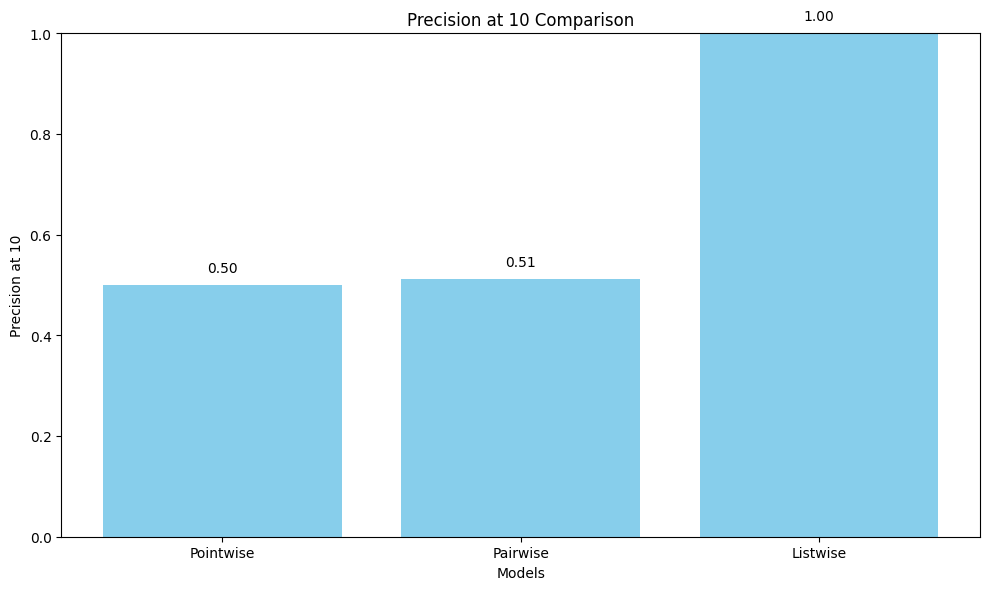

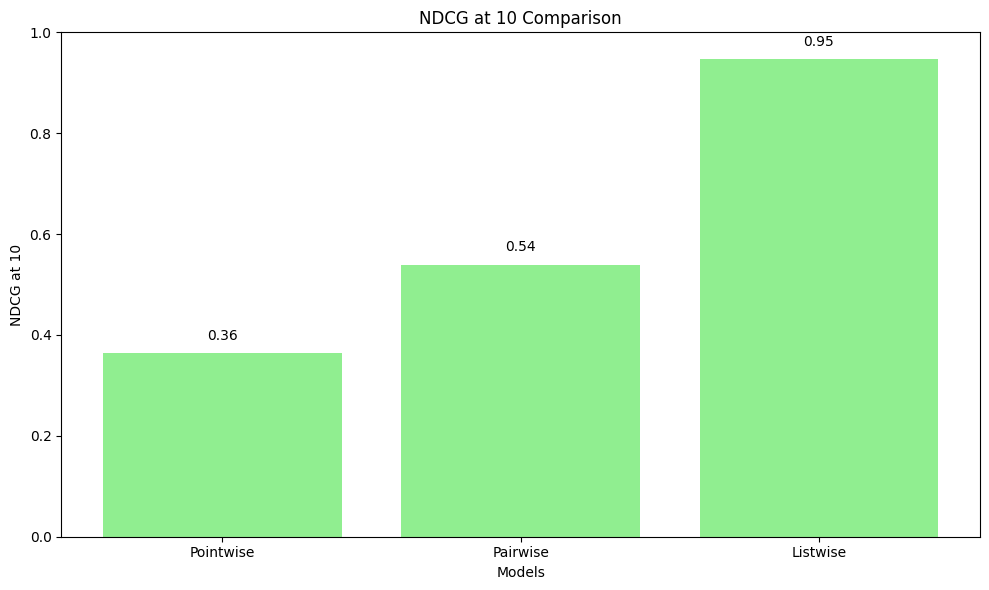

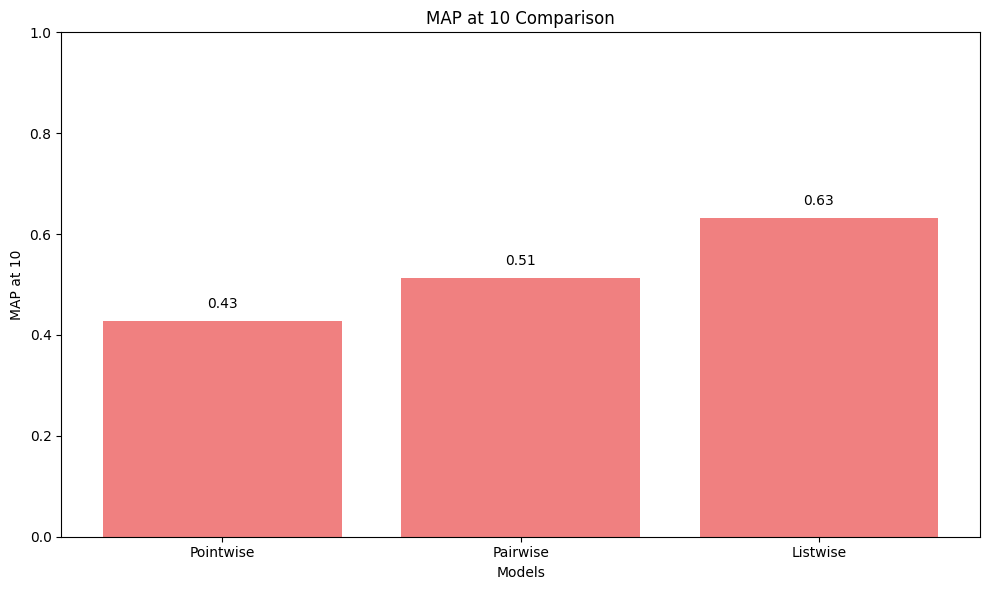

In [49]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Pointwise', 'Pairwise', 'Listwise']


plt.figure(figsize=(10, 6))
plt.bar(models, [pointwise_precision_at_10, pairwise_precision_at_10, listwise_precision_at_10], color='skyblue')
plt.title('Precision at 10 Comparison')
plt.xlabel('Models')
plt.ylabel('Precision at 10')
plt.ylim(0, 1)
for i, v in enumerate([pointwise_precision_at_10, pairwise_precision_at_10, listwise_precision_at_10]):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')  
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, [pointwise_ndcg_at_10, pairwise_ndcg_at_10, listwise_ndcg_at_10], color='lightgreen')
plt.title('NDCG at 10 Comparison')
plt.xlabel('Models')
plt.ylabel('NDCG at 10')
plt.ylim(0, 1)
for i, v in enumerate([pointwise_ndcg_at_10, pairwise_ndcg_at_10, listwise_ndcg_at_10]):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')  
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(models, [pointwise_map_score, pairwise_map_score, listwise_map_score], color='lightcoral')
plt.title('MAP at 10 Comparison')
plt.xlabel('Models')
plt.ylabel('MAP at 10')
plt.ylim(0, 1)
for i, v in enumerate([pointwise_map_score, pairwise_map_score, listwise_map_score]):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom') 
plt.tight_layout()
plt.show()


# **نکات مهم**

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
    <p><strong>مهلت تحویل بدون جریمه:</strong> ۱۲ آذر ۱۴۰۳</p>
    <p><strong>مهلت تحویل با تاخیر (با جریمه):</strong> ۱۹ آذر ۱۴۰۳</p>
</div>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">فایل ارسالی شما باید با فرمت زیر نامگذاری شود: <code>IIR_CA4_STUDENTID.ipynb</code></h4>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">نحوه انجام این تمرین:</h4>
<ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>برخی سوالات نیاز به نوشتن کد پایتون و محاسبه نتایج دارند کدها بایستی طبق فایل تمرین به طور کامل نوشته شوند.</li> <li> کدها و تفسیرهای هربخش را به طور مشخص در همین نوت‌بوک بنویسید. سعی کنید هربخش به طور مشخصی جداشده باشد و ساختار نوت‌بوک خوانا باشد.</li>  </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">صداقت علمی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>ما نوت‌بوک‌های تعداد مشخصی از دانشجویان که به صورت تصادفی انتخاب می‌شوند، بررسی خواهیم کرد. این بررسی‌ها اطمینان حاصل می‌کنند که کدی که نوشتید واقعاً پاسخ‌های موجود در نوت‌بوک شما را تولید می‌کند. اگر پاسخ‌های صحیح را در نوت‌بوک خود بدون کدی که واقعاً آن پاسخ‌ها را تولید کند تحویل دهید، این یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> <li>ما همچنین بررسی‌های خودکاری را برای تشخیص سرقت علمی در نوت‌بوک‌های کولب انجام خواهیم داد. کپی کردن کد از دیگران نیز یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">توضیحات تکمیلی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<li>
خوانایی و دقت بررسی‌ها در گزارش نهایی از اهمیت ویژه‌ای برخوردار است. به تمرین‌هایی که به صورت کاغذی تحویل داده شوند یا به صورت عکس در سایت بارگذاری شوند، ترتیب اثری داده نخواهد شد.</li>
<li>
 همه‌ی کدهای پیوست گزارش بایستی قابلیت اجرای مجدد داشته باشند. در صورتی که برای اجرا مجدد آن‌ها نیاز به تنظیمات خاصی می‌باشد، بایستی تنظیمات مورد نیاز را نیز در گزارش خود ذکر کنید.  دقت کنید که  تمامی کدها باید توسط شما اجرا شده باشند و نتایج اجرا در فایل کدهای ارسالی مشخص باشد. به کدهایی که نتایج اجرای آن‌ها در فایل ارسالی مشخص نباشد نمره‌ای تعلق نمی‌گیرد.
</li>
<li>
تمرین تا یک هفته بعد از مهلت تعیین شده با تاخیر تحویل گرفته می‌شود. دقت کنید که شما جمعاً برای تمام تکالیف، ۱۴ روز زمان تحویل بدون جریمه دارید که تنها از ۷ روز آن برای هر تمرین می‌توانید استفاده کنید. در صورتی که این ۱۴ روز به اتمام رسیده باشد، به ازای هر روز تاخیر ده درصد جریمه می‌شود.
</li>
<li>توجه کنید این تمرین باید به صورت تک‌نفره انجام شود و پاسخ‌های ارائه شده باید نتیجه فعالیت فرد نویسنده باشد (همفکری و به اتفاق هم نوشتن تمرین نیز ممنوع است). در صورت مشاهده
 تشابه به همه افراد مشارکت‌کننده، نمره تمرین صفر و به استاد گزارش می‌گردد.
 </li>
 <li>برای مطالعه بیشتر درباره‌ی فرمت مارک‌دون می‌توانید از <a href="https://github.com/tajaddini/Persian-Markdown/blob/master/learn-MD.md">این لینک</a> مطالعه کنید.
 </li>

 </ul>
 </div>